## Benchmark Dataset 1

The first dataset to be employed as a benchmark for the implementation of the $L_2$-TWSVM and $L_1$-TWSVM models (with feature selection per hyperplane) was provided from the University of California, Irvine (UCI) Machine Learning Repository. This dataset consists of 13 clinical attributes collected from a cohort of up to 303 patients.

The original target variable encodes the presence and severity of coronary artery disease, assigning values from 0 to 4, where 0 denotes absence of disease and values 1 through 4 correspond to different severity of diagnosed heart disease. For the purposes of this study, the problem is reformulated as a binary classification task by aggregating all non-zero categories into a single positive class, thereby distinguishing between patients with heart disease and those without.

This dataset is typically used as a benchmark to evaluate the performance of $SVM$, $L_2$-TWSVM and $L_1$-TWSVM models, with particular emphasis on their performance handling clinical binary classification problems.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

# Random seed
init_seed = 100453109

# Fetch the desired dataset from University of California, Irvine's Machine Learning Repository
heart_disease = fetch_ucirepo(id=45) 

# Store Benchmark dataset as pandas
X = heart_disease.data.features
Y = heart_disease.data.targets

# Remove NAs from the entire dataset
data = pd.concat([X, Y], axis = 1).dropna()
X = data.drop(columns = ['num'])
# Store feature names as numpy array (for representing feature importance)
features_names = np.array(X.columns)
Y = data[['num']]
Y = pd.DataFrame(np.where(Y == 0, 1, -1), columns = ['target'])

# Distribution of target classes (significant imbalance on target distribution)
print('Shape of features benchmark dataset 1 {}'.format(X.shape)) # Notice the original size of the dataset was 303 (just 6 patients observations were removed due to NAs values)
print('Distribution of target variable')
print(100 * Y.value_counts() / len(Y))
print('Unique classes', Y.nunique())

Shape of features benchmark dataset 1 (297, 13)
Distribution of target variable
target
 1        53.872054
-1        46.127946
Name: count, dtype: float64
Unique classes target    2
dtype: int64


## Benchmark Dataset 2

The second benchmark dataset was also provided by the UCI's Machine Learning Repository and comprises 569 observations of breast cancer clinical patients in the state of Wisconsin over 30 different features computed from digitalized images of a fine needle aspirate (FNA) of breast mass.

In [10]:
#Fetch the desired dataset as a dictionary
breast_cancer_dataset = fetch_ucirepo(id = 17)

# Store the desired data as pandas datasets
X = breast_cancer_dataset.data.features
Y = breast_cancer_dataset.data.targets
# Store feature names numpy array
features_names = np.array(X.columns)
# Encode the Y target dataset, 'B' (Benign) == positive class, +1, 'M' (Malign) == negative class, -1
Y = pd.DataFrame(np.where(Y == 'B', 1, -1), columns = ['target'])

# Distribution of target classes (significant imbalance on target distribution)
print('Shape of features benchmark dataset 2 {}'.format(X.shape))
print('Distribution of target variable')
print(100 * Y.value_counts() / len(Y))
print('Unique classes', Y.nunique())

Shape of features benchmark dataset 2 (569, 30)
Distribution of target variable
target
 1        62.741652
-1        37.258348
Name: count, dtype: float64
Unique classes target    2
dtype: int64


## Benchmark Dataset 3

In [27]:
from scipy.stats import multivariate_normal
from sklearn.utils import shuffle

def artificial_dataset(n_pos: int, n_neg: int, class_sep = 6.0, n_noise = 10):
    '''
    The function creates an artificial dataset composed by two informative features 
    which by construction determine the target variable, y. The two informative features
    are built from two multivariate gaussian distributions one of each identifies one class of the target variable
    The function takes two default parameters class_sep and n_noise which define the separation between
    classes affecting the mean of each multivariate gaussian associated with each target's class as well as the
    number of noisy features to be included in the dataset, respectively.
    The main parameters received by the function are n_pos and n_neg which controls the number
    of observations to be created of each class.
    '''
    mu_pos = np.array([class_sep / 2, class_sep / 2])
    mu_neg = np.array([-class_sep / 2, - class_sep / 2])
    cov = np.diag([0.6, 0.6])
    # Create two informative features identifying the two classes
    X_pos = multivariate_normal.rvs(mean = mu_pos, cov = cov, random_state = init_seed, size = n_pos)
    X_neg = multivariate_normal.rvs(mean = mu_neg, cov = cov, random_state = init_seed - 1, size = n_neg)
    X_informative = np.vstack([X_pos, X_neg])

    mu_noise = np.zeros(n_noise)
    cov_noise = np.eye(n_noise)
    X_noise = multivariate_normal.rvs(mu_noise, cov_noise, random_state= init_seed -2, size = n_pos + n_neg)

    X = np.hstack([X_informative, X_noise])
    Y_plus = np.ones(n_pos)
    Y_neg = - np.ones(n_neg)
    Y = np.hstack([Y_plus, Y_neg])

    X, Y = shuffle(X, Y, random_state = init_seed)
    features_names = np.array(['informative1', 'informative2'] + [f'noise{i+1}' for i in range(n_noise)])
    
    X = pd.DataFrame(X, columns = features_names)
    Y = pd.DataFrame(Y, columns = ['target'])

    return X, Y, features_names

X, Y, features_names = artificial_dataset(800, 200)

In [ ]:
# Holdout as outer evaluation, estimation of future performance
# (stratification ensures similar target distribution on train- test split)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2, random_state= init_seed, 
                                                    shuffle = True, stratify = Y)

# Convert the splits into numpy arrays to better handle them
X_train = X_train.to_numpy()
Y_train = Y_train['target'].to_numpy().ravel()
X_test = X_test.to_numpy()
Y_test = Y_test['target'].to_numpy().ravel()

## Soft margin TWSVM (Standard $L_2$-TWSVM)

The soft margin TWSVM is defines as,
$$
\begin{align*}
& \min_{w_1, b_1, \xi_2}\frac{1}{2}\|Aw_1+e_1b_1\|^2 + c_1e_2^T \xi_2 \\
& \text{s.t} \\

& \begin{cases} 
& -(Bw_1+e_2b_1)+\xi_2 \geq e_2 \\
& \xi_2 \geq 0
\end{cases} \\

& \text{and} \\
& \min_{w_2, b_2, \xi_1}\frac{1}{2}\|Bw_2+e_2b_2\|^2 + c_2e_1^T \xi_1 \\
& \text{s.t} \\

& \begin{cases} 
& Aw_2+e_1b_2 +\xi_1 \geq e_1 \\
& \xi_1 \geq 0
\end{cases}

\end{align*}
$$

where, $w_1, w_2 \in R^{N}$, $b_1, b_2 \in \R$ and $\xi_1 \in R^{m_1}$ $\xi_2 \in R^{m_2}$ are the variables to be optimized. Meanwhile, $e_1 = \vec{1} \in R^{m_1}$, $e_2 = \vec{1} \in R^{m_2}$ and the matrices containing the observations of each of the classes $A \in R^{m_1xN}$ (class 1 obs), $B \in R^{m_2xN}$ (class -1 obs) are given. Moreover, $c_1, c_2 \in \R$ are hyperparameters controlling the trade-off between margin violations penalization and least square fitting.

In [13]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# Gurobi supports QP
solver = pyo.SolverFactory('gurobi')

# Dimensions of class 1, class -1 datasets
A_nrows, A_ncols = A.shape
B_nrows, B_ncols = B.shape

# hyperparameters controlling penalization
c1 = 1.0
c2 = 2.2

In [14]:
model_1 = pyo.ConcreteModel('Soft Margins TWSVM 1')

# Sets in TWSVM 1
model_1.N = pyo.RangeSet(0, A_ncols - 1) # number of features
model_1.I = pyo.RangeSet(0, A_nrows - 1) # number of class 1 observations
model_1.J = pyo.RangeSet(0, B_nrows - 1) # number of class -1 observations

# Variables for TWSVM 1
# Variables defining hyperplane for class 1
model_1.w1 = pyo.Var(model_1.N, domain = pyo.Reals)
model_1.b1 = pyo.Var(domain=pyo.Reals)

# Slack variables hyperplane class -1
model_1.xi2 = pyo.Var(model_1.J, domain = pyo.NonNegativeReals)

# TWSVM 1 objective
def h1_objective(model_1):
    ls_term = sum(
        (sum(A[i,n] * model_1.w1[n] for n in model_1.N) + model_1.b1)**2
        for i in model_1.I
        )
    penalt_term = c1 * sum(model_1.xi2[j] for j in model_1.J)
    
    return 0.5 * ls_term + penalt_term

model_1.obj1 = pyo.Objective(rule = h1_objective, sense = pyo.minimize)

# TWSVM 1 constraint
def h1_constraint(model_1, j):
    return -(sum(B[j,n] * model_1.w1[n] for n in model_1.N) + model_1.b1) + model_1.xi2[j] >= 1

model_1.constraint1 = pyo.Constraint(model_1.J, rule = h1_constraint)

# TWSVM 1 solution
solutions_h1 = solver.solve(model_1, tee = True)

Read LP format model from file C:\Users\danie\AppData\Local\Temp\tmp7ub177ke.pyomo.lp
Reading time = 0.07 seconds
x1: 240 rows, 253 columns, 3360 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 240 rows, 253 columns and 3360 nonzeros (Min)
Model fingerprint: 0x0a02deb9
Model has 240 linear objective coefficients
Model has 91 quadratic objective terms
Coefficient statistics:
  Matrix range     [2e-03, 5e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 9e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]

Presolve time: 0.01s
Presolved: 240 rows, 253 columns, 3360 nonzeros
Presolved model has 91 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 25
 AA' NZ     : 3.163e+04
 Factor NZ  : 

In [15]:
# Retrieve w1*
twsvm_opt_w1 = np.array([pyo.value(model_1.w1[n]) for n in model_1.N])
print(f'w1* ={twsvm_opt_w1}')
# Retrieve b1*
twsvm_opt_b1 = pyo.value(model_1.b1)
print(f'b1* ={twsvm_opt_b1}')
# retrieve slack variable xi2 associated to H1
opt_xi2 = np.array([pyo.value(model_1.xi2[j]) for j in model_1.J])

w1* =[ 0.10317086  0.09732711  0.00631998  0.00093824  0.00693296  0.00271788
 -0.00461018  0.00351266  0.00422367 -0.01122131 -0.00141245  0.00024394]
b1* =-0.6138575248612846


In [16]:
model_2 = pyo.ConcreteModel('Soft Margin TWSVM 2')

# Sets for TWSVM 2
model_2.N = pyo.RangeSet(0, A_ncols - 1) # number of features
model_2.I = pyo.RangeSet(0, A_nrows - 1) # number of class 1 observations
model_2.J = pyo.RangeSet(0, B_nrows - 1) # number of class -1 observations

# Variables defining hyperplane for class 2
model_2.w2 = pyo.Var(model_2.N, domain = pyo.Reals)
model_2.b2 = pyo.Var(domain=pyo.Reals)

# Slack variables hyperplane class 1
model_2.xi1 = pyo.Var(model_2.I, domain = pyo.NonNegativeReals)

# TWSVM 2 objective
def h2_objective(model_2):
    ls_term = sum(
            (sum(B[j,n] * model_2.w2[n] for n in model_2.N) + model_2.b2)**2
        for j in model_2.J
    )
    penalt_term = c2 * sum(model_2.xi1[i] for i in model_2.I)

    return 0.5 * ls_term + penalt_term

model_2.obj2 = pyo.Objective(rule = h2_objective, sense = pyo.minimize)

# TWSVM 2 constraint
def h2_constraint(model_2, i):
    return sum(A[i,n] * model_2.w2[n] for n in model_2.N) + model_2.b2 + model_2.xi1[i] >= 1

model_2.constraint2 = pyo.Constraint(model_2.I, rule = h2_constraint)

# solutions TWSVM 2
solutions_h2 = solver.solve(model_2, tee = True)

Read LP format model from file C:\Users\danie\AppData\Local\Temp\tmpnmqcciz4.pyomo.lp
Reading time = 0.06 seconds
x1: 480 rows, 493 columns, 6720 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 480 rows, 493 columns and 6720 nonzeros (Min)
Model fingerprint: 0xbaa3b1fb
Model has 480 linear objective coefficients
Model has 91 quadratic objective terms
Coefficient statistics:
  Matrix range     [5e-04, 6e+00]
  Objective range  [2e+00, 2e+00]
  QObjective range [4e-01, 4e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]

Presolve time: 0.02s
Presolved: 480 rows, 493 columns, 6720 nonzeros
Presolved model has 91 quadratic objective terms
Ordering time: 0.02s

Barrier statistics:
 Free vars  : 25
 AA' NZ     : 1.208e+05
 Factor NZ  : 

In [17]:
# w2*
twsvm_opt_w2 = np.array([pyo.value(model_2.w2[n]) for n in model_2.N])
print(f'w2* ={twsvm_opt_w2}')
# b2*
twsvm_opt_b2 = pyo.value(model_2.b2)
print(f'b2* ={twsvm_opt_b2}')
# Slack variable xi1 associated with H2
opt_xi1 = np.array([pyo.value(model_2.xi1[j]) for j in model_2.I])

w2* =[ 0.11329658  0.09589723  0.0178717   0.00644965 -0.00915146 -0.00954134
 -0.00116748 -0.00285186 -0.00305381  0.0053487  -0.00302613 -0.00427549]
b2* =0.6342985987552222


## TWSVM with Embedded Feature Selection ($L_1$-TWSVM)

L1-TWSVM introduces $L_1$ norm of the regularization terms of each hyperplane namely, $Aw_1 + e_1b_1$ and $Bw_2 + e_2b_2$, as well as the $L_1$-norm of the weights vectors $w_i$, $i=1, 2$ as in Bai, L. Wang, Z. Shao Y.H & Deng, N. Y (2014)

$$
\begin{align*}
&\min_{w_1, b_1, \xi_2}\;\; \|w_1\|_1 + c_1\|Aw_1+e_1b_1\|_1 + c_3e_2^T\xi_2 \\
&\text{s.t} \\
&\begin{cases}
& -(Bw_1+e_2b_1) \geq e_2 - \xi_2 \\
& \xi_2 \geq 0
\end{cases} \\
&\text{and} \\[2ex]
&\min_{w_2, b_2, \xi_1}\;\;\|w_2\|_1 + c_2\|Bw_2+e_2b_2\|_1 + c_4e_1^T\xi_1 \\
&\text{s.t} \\
&\begin{cases}
& (Aw_2+e_1b_2) \geq e_1 - \xi_1 \\
& \xi_1 \geq 0
\end{cases}
\end{align*}
$$

The earlier representation of the $L_1$-TWSVM compose a Nondifferentiable Programming Problem due to the presence on the objective function of non linear term as, $\|w_1\|_1 = \sum_{n=1}^N|w_n^{(1)}|$ and $\|Aw_1+e_1b_1\|_1 = \sum_{i=1}^{m_1}|\sum_{n=1}^Na_{i,n}w_n^{(1)} + b_1|$ in the definition of the first TWSVM hyperplane.

This problem can be transformed into a Differentiable Linear Programming Problem (DLPP) to be solved by the version of the Simplex algorithm implemented by the Gurobi optimizer just by introducing the following auxiliar variables, $w_i = p_i - q_i$ as well as, $Aw_1 + e_ib_1 = s_1 - t_i$ and $Bw_2 + e_2b_2 = s_2 - t_2$.

The auxiliary variables introduce a positive-negative decomposition of the weight vectors and residual terms, where each variable is expressed as the difference of two nonnegative variables. This allows their absolute values to be represented as the sum of these components, thereby enabling a linear formulation of the $L_1$-TWSVM.

\begin{align*}
& \min_{p_1,q_1,s_1,t_1,b_1,\xi_2} e_1^T(p_1 + q_1) + c_1e_1^T(s_1 + t_1) + c_3e_1^T\xi_1 \\
& \text{s.t} \\
& \begin{cases}
& A(p_1 - q_1) + e_1b_1 = s_1 - t_1 \\
& -B(p_1 - q_1) + e_2b_1 \geq e_2 - \xi_2 \\
& p_1, q_1, s_1, t_1, \xi_2 \geq 0
\end{cases} \\
& \text{and} \\
& \min_{p_2,q_2,s_2,t_2,b_2,\xi_1} e_2^T(p_2 + q_2) + c_2e_2^T(s_2 + t_2) + c_4e_2^T\xi_1 \\
& \text{s.t} \\
& \begin{cases}
& B(p_2 - q_2) + e_2b_2 = s_2 - t_2 \\
& A(p_2 - q_2) + e_1b_2 \geq e_1 - \xi_1 \\
& p_2,q_2,s_2,t_2,\xi_1
\end{cases}
\end{align*}

Noticing, $s_1 = A(p_1 - q_1) + e_1b_1 + t_1$ and $s_2 = B(p_2 - q_2) + e_2b_2 + t_2$ the final DLPPs to be solved by Gurobi's Simplex algorithm implementation are defined,

$$
\begin{align*}
& \min_{p_1,q_1,t_1,b_1,\xi_2} e_1^T(p_1+q_1) + c_1e_1^T(A(p_1 -q_1) + 2t_1) + c_1m_1b_1 + c_3e_1^T\xi_2 \\
& \text{s.t} \\
& \begin{cases}
& A(p_1 - q_1) + e_1b_1 + t_1 \geq 0 \\
& -B(p_1-q_1) + e_2b_1 \geq e_2 - \xi_2 \\
& p_1, q_1, t_1, \xi_2 \geq 0 
\end{cases} \\
& \text{and} \\
& \min_{p_2,q_2,t_2,b_2,\xi_1} e^T(p_2 + q_2) + c_2e^T(B(p_2 - q_2) + 2t_2) + c_2m_2b_2 + c_4e^T\xi_1 \\
& \text{s.t} \\
& \begin{cases}
& B(p_2-q_2) + e_2b_2 + t_2 \geq 0 \\
& A(p_2-q_2) + e_1b_2 \geq e_1 - \xi_1 \\
& p_2,q_2,t_2,\xi_1 \geq 0
\end{cases}
\end{align*}
$$

where $m_1 = e_1^Te_1$ and $m_2 = e_2^Te_2$ denote the total training observations of each class respectively.

**Post Hoc Feature Selection**

$L_1$-TWSVM directly compose an individual feature selection method per hyperplane by imposing sparsity on the weight vectors corresponding to each hyperplane such that the less relevant features see its weights be collapsed to zero. Each hyperplane selects relevant features by discarding those which weights are zero. Namely, $n_1$ would represent the set of significant features selected by solving the first $L_1$-TWSVM hyperplane and similarly $n_2$ for the second $L_1$-TWSVM hyperplane. 

## Probability model for FTWSVM (TWSVM with Feature Selection)

Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012) propose a continuous scoring function to approximate the posterior probability of a sample $\tilde{x}$ belonging to a class. This score is constructed based on the geometric position of the sample $\tilde{x}$ relative to two auxiliary hyperplanes,
$$
\begin{cases}
\frac{w_1^T\tilde{x} + b_1}{\|w_1\|} - \frac{w_2^T\tilde{x} + b_2}{\|w_2\|} = 0 \\
\frac{w_1^T\tilde{x} + b_1}{\|w_1\|} + \frac{w_2^T\tilde{x} + b_2}{\|w_2\|} = 0
\end{cases}
$$

Defined the distances from the sample to those auxiliarly hyperplanes, $D_+(x) = \frac{|d_1(x) + d_2(x)|}{\|\frac{w_1}{\|w_1\|} + \frac{w_2}{\|w_2\|}\|}$ and $D_-(x) = \frac{|d_1(x) - d_2(x)|}{\|\frac{w_1}{\|w_1\|} - \frac{w_2}{\|w_2\|}\|}$, thus it can be identified the maximum and minimum distance from the sample to either auxiliarly hyperplane, $d(x)$ and $D(x)$ such that the relevant quantities $d(x)$ and $\frac{d(x)}{D(x)}$ can be defined.

It is observed that the higher either $d(x)$ or $\frac{d(x)}{D(x)}$ are the more likely a sample belongs to the positive class. Therefore the score function is defined as,

$$
f(x) = \begin{cases} d(x)(\frac{d(x)}{D(x)})^{\alpha} &\frac{|w_1^T\tilde{x} + b_1|}{\|w_1\|} < \frac{|w_2^T\tilde{x} + b_2|}{\|w_2\|}  \\
0 & \frac{|w_1^T\tilde{x} + b_1|}{\|w_1\|} = \frac{|w_2^T\tilde{x} + b_2|}{\|w_2\|} \\
-d(x)(\frac{d(x)}{D(x)})^{\alpha} & \frac{|w_1^T\tilde{x} + b_1|}{\|w_1\|} > \frac{|w_2^T\tilde{x} + b_2|}{\|w_2\|}
\end{cases}
$$

**Platt scaling probability model**

The probability model can be constructed by using a sigmoid to transform the results yielded by the earlier function into probabilities,

$$
P(y= +1| f(x)) = \frac{1}{1 + e^{af(x) + b}} \\
p(y = -1| f(x)) = 1 - P(y = +1 | f(x))
$$

Setting the weight parameter $\alpha = 1$, the parameters $a, b$ for the sigmoid can be obtained by minimizing the cross- entropy between predicted probabilities $p_i$ and  target probabilities $t_i$ in the following convex optimization problem,

$$
\begin{align*}
\min_{a,b} \;& - \sum_{i=1}^m \Big( t_i \log(p_i) + (1-t_i) \log(1-p_i) \Big) \\
\text{s.t.} \;& p_i = P(y = +1 \mid f(x_i)), \\
&t_i = 
\begin{cases} 
\dfrac{m_1 + 1}{m_1 + 2}, & \text{if } y_i = +1,\\[1em]
\dfrac{1}{m_2 + 2}, & \text{if } y_i = -1.
\end{cases}
\end{align*}
$$

Notice, the target probabilities $t_i$ are defined by Laplace smoothing.

**Polynomial Logistic, probability model**

Instead of the sigmoid proposed by Platt (2000), a polyinomial logistic function can be implemented for converting the confidence scores yielded by the previous function $f(x)$ into probabilities.
$$
P(y = 1| f(x)) = \frac{1}{1 + e^{af(x)^2 + bf(x) + c}}
$$

In [74]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
from scipy.optimize import minimize

class PTWSVM():
    '''
    Describe class behaviour
    '''

    def __init__(self, c1: float, c2: float, c3: float, c4:float):

        # Store input TWSVM parameters within class instances (self)
        self.c1 = c1
        self.c2 = c2
        self.c3 = c3
        self.c4 = c4
        # Initialize containers for optimum TWSVM parameters w1_, b1_, w2_, b2_
        self.w1_, self.b1_, self.w2_, self.b2_ = None, None, None, None

        # Initialize Platt scaling parameters, (a,b), later optimized within fit_probabilities()
        self.a, self.b = 0.0, 0.0
        # Initialize Polynomial logistic parameter
        self.c = 0.0
        # Initialize containers for optimum a, b, c parameters to be obtained at fit_probabilities()
        self.a_, self.b_, self.c_ = None, None, None
    

    # TWSVM 1 Construction
    def build1(self):
        # Define pyomo model object
        model1 = pyo.ConcreteModel('FTWSVM_1')

        # model Sets
        model1.N = pyo.RangeSet(0, self.A_ncols -1) # dim number
        model1.I = pyo.RangeSet(0, self.A_nrows -1) # m1, num obs class 1
        model1.J = pyo.RangeSet(0, self.B_nrows -1) # m2, num obs class -1

        # model variables
        model1.b1 = pyo.Var(domain = pyo.Reals)
        model1.xi2 = pyo.Var(model1.J, domain = pyo.NonNegativeReals)
        # Aux vars for computing the abs value of w_1 as |w_1| = p1 + q1
        model1.p1 = pyo.Var(model1.N, domain = pyo.NonNegativeReals) # Aux var p1 (w_1 = p1 - q1)
        model1.q1 = pyo.Var(model1.N, domain = pyo.NonNegativeReals) # Aux var q1 (w_1 = p1 - q1)
        # Aux vars for computing the abs value of Aw_1 + e_1b_1 as |Aw_1 + e_1b_1| = s1 + t1
        model1.t1 = pyo.Var(model1.I, domain = pyo.NonNegativeReals) # Aux var t1 (Aw_1 + e_1b_1 = s_1 - t_1)

        # TWSVM 1 Objective function
        def h1_objective(model1):
            fs_term = sum((model1.p1[n] + model1.q1[n]) for n in model1.N)
            ls_term1 = sum(
                sum(self.A[i,n] * (model1.p1[n] - model1.q1[n]) for n in model1.N) + 2 * model1.t1[i]
                for i in model1.I
            )
            ls_term2 = len(model1.I) * model1.b1
            penalty_term = sum(model1.xi2[j] for j in model1.J)
            return fs_term + self.c1 * ls_term1 + self.c1 * ls_term2 + self.c3 * penalty_term

        model1.obj = pyo.Objective(rule = h1_objective, sense = pyo.minimize)

        # TWSVM 1 s1 aux variable definition constraint
        def h1Constraint_1(model1, i):
            return sum(self.A[i,n] * (model1.p1[n] - model1.q1[n]) for n in model1.N) + model1.t1[i] + model1.b1 >= 0

        model1.constraint1 = pyo.Constraint(model1.I, rule = h1Constraint_1)

        # TWSVM 1 h2 hyperplane separation constraint with margin violations
        def h1Constraint_2(model1, j):
            return -(sum(self.B[j,n] * (model1.p1[n] - model1.q1[n]) for n in model1.N) + model1.b1) >= 1 - model1.xi2[j]

        model1.constraint2 = pyo.Constraint(model1.J, rule = h1Constraint_2)

        self.model1 = model1
    

    def solve1(self, tee = False, solver = 'gurobi'):
        self.solver = pyo.SolverFactory(solver)
        self.solver.solve(self.model1, tee = tee)

        model1 = self.model1
        # Recover w1 as w1 = p1 - q1
        self.w1_ = np.array([pyo.value(model1.p1[n]) - pyo.value(model1.q1[n]) for n in model1.N])
        self.b1_ = pyo.value(model1.b1)
        self.xi2_ = np.array([pyo.value(model1.xi2[j]) for j in model1.J])

    
    # TWSVM 2 Construction
    def build2(self):
        # Pyomo model object
        model2 = pyo.ConcreteModel('FTWSVM_2')

        # Model Sets
        model2.N = pyo.RangeSet(0, self.A_ncols -1) #dimensionality
        model2.I = pyo.RangeSet(0, self.A_nrows -1) # m1, number of class 1 observations
        model2.J = pyo.RangeSet(0, self.B_nrows -1) # m2, number of class -1 observations

        # Variables
        model2.b2 = pyo.Var(domain = pyo.Reals)
        model2.xi1 = pyo.Var(model2.I, domain = pyo.NonNegativeReals)
        # Aux vars for computing the abs value of w_2 as |w_2| = p2 + q2
        model2.p2 = pyo.Var(model2.N, domain = pyo.NonNegativeReals) # Aux var p1 (w_2 = p2 - q2)
        model2.q2 = pyo.Var(model2.N, domain = pyo.NonNegativeReals) # Aux var q1 (w_2 = p2 - q2)
        # Aux vars for computing the abs value of Bw_2 + e_2b_2 as |Bw_2 + e_2b_2| = s2 + t2
        model2.t2 = pyo.Var(model2.J, domain = pyo.NonNegativeReals) # Aux var t2 (Bw_2 + e_2b_2 = s_2 - t_2)

        # TWSVM 2 Objective function
        def h2_objective(model2):
            fs_term = sum((model2.p2[n] + model2.q2[n]) for n in model2.N)
            ls_term1 = sum(
                sum(self.B[j,n] * (model2.p2[n] - model2.q2[n]) for n in model2.N) + 2 * model2.t2[j]
                for j in model2.J
            )
            ls_term2 = len(model2.J) * model2.b2
            penalty_term = sum(model2.xi1[i] for i in model2.I)
            return fs_term + self.c2 * ls_term1 + self.c2 * ls_term2 + self.c4 * penalty_term

        model2.obj = pyo.Objective(rule = h2_objective, sense = pyo.minimize)

        # TWSVM 1 s1 aux variable definition constraint
        def h2Constraint_1(model2, j):
            return sum(self.B[j,n] * (model2.p2[n] - model2.q2[n]) for n in model2.N) + model2.t2[j] + model2.b2 >= 0

        model2.constraint1 = pyo.Constraint(model2.J, rule = h2Constraint_1)

        # TWSVM 1 h2 hyperplane separation constraint with margin violations
        def h2Constraint_2(model2, i):
            return (sum(self.A[i,n] * (model2.p2[n] - model2.q2[n]) for n in model2.N) + model2.b2) >= 1 - model2.xi1[i]

        model2.constraint2 = pyo.Constraint(model2.I, rule = h2Constraint_2)

        self.model2 = model2

    
    def solve2(self, tee = False, solver = 'gurobi'):
        self.solver = pyo.SolverFactory(solver)
        self.solver.solve(self.model2, tee = tee)

        m2 = self.model2
        # Retrieve w2, w2 = p2 - q2
        self.w2_ = np.array([pyo.value(m2.p2[n]) - pyo.value(m2.q2[n]) for n in m2.N])
        self.b2_ = pyo.value(m2.b2)
        self.xi1_ = np.array([pyo.value(m2.xi1[i]) for i in m2.I])


    def fit(self, X_train: np.array, Y_train: np.array):
        '''
        Accepts X_train, Y_train numpy arrays for generating and storing standard A, B training matrices
        Assumes a binary target variable encoding positive (negative) class observations with ones (minus ones)
        The fit methods internally calls to  the build() and solve() methods for both TWSVM hyperplanes
        The object to be returned by the fit() method is the own class instance transformed
        After, being fitted into the training sample the instance object includes the optimal parameters defining both TWSVM hyperplanes
        denoted as, w1_, b1_, w2_ and b2_.
        '''
        # Store the training data (A = class 1 training instances, B = class -1 training instance)
        self.A  = X_train[Y_train == 1].to_numpy() # (class 1) No Heart disease/ Benign training observations
        self.B = X_train[Y_train == -1].to_numpy() # (class -1) Heart Disease/ Malign training observations

        # Store the shape of the training data
        self.A_nrows, self.A_ncols = self.A.shape
        self.B_nrows, self.B_ncols = self.B.shape


        # If a ptsvm instance has already been created and fitted delete the previous models from memory
        if hasattr(self, 'model1'):
            del self.model1
        if hasattr(self, 'model2'):
            del self.model2

        # If there are previous instances of the ptsvm class forze garbage collector to free memory
        import gc
        gc.collect()


        # Build and solve TWSVM H1 QPP problem
        self.build1()
        self.solve1()

        # Build and solve TWSVM H2 QPP problem
        self.build2()
        self.solve2()

        return self


    def feature_selection(self, n_star: int):
        # Extract the indexes of the set of features selected on each TWSVM hyperplane
        n1 = set(np.where(self.w1_ != 0)[0])
        n2 = set(np.where(self.w2_ != 0)[0])

        # Extract the union of the n1, n2 set of features indexes WITHOUT DUPLICATES
        union = n1 | n2

        # Compute the sum of the absolute weight values on both TWSVM hyperplane, 
        # THIS IS USED as a post- hoc measure of total relevance of the features for ensuring the |n1 U n2| <= n* global restriction
        union_weights = {j: np.abs(self.w1_[j]) + np.abs(self.w2_[j]) for j in union}

        # Sort in descending order features by feature importance
        sorted_features = sorted(union_weights, key = union_weights.get, reverse = True)

        if len(union) > n_star:
            selected_features = sorted_features[:n_star]
        else:
            selected_features = sorted_features
        
        selected_weights = [union_weights[j] for j in selected_features]

        return selected_features, selected_weights


    def score_function(self, x: np.array, alpha = 1):
        '''
        Compute the FTWSVM scores as defined in Shao, Y. H., Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012)
        Assume alpha = 1 allowing the later cross entropy minimization for obtaining the optimum sigmoid parameters a, b.
        '''
        # Retrieve the optimum parameters obtained solving the TWSVM opt problems
        w1, b1, w2, b2 = self.w1_, self.b1_, self.w2_, self.b2_
        # numeric stabilization
        eps = 1e-12

        # Weight vectors norms
        norm_w1 = max(np.linalg.norm(w1), eps)
        norm_w2 = max(np.linalg.norm(w2), eps)

        # euclidean distances to the separation hyperplanes derived from TWSVM
        d1 = (x @ w1 + b1) / norm_w1
        d2 = (x @ w2+ b2) / norm_w2

        # Normalized weight vectors
        w1_hat = w1 / norm_w1
        w2_hat = w2 / norm_w2

        # euclidean distances to the auxiliarly hyperplanes defined
        # the resulting D_plus, D_minus vectors have shape (n, ) measuring 
        # the euclidean dist to the each aux hyperplane (angle bisectors of the TWSVM hyperplanes) for each n observation
        D_plus = np.abs(d1 + d2) / max(np.linalg.norm(w1_hat + w2_hat), eps)
        D_minus = np.abs(d1 - d2) / max(np.linalg.norm(w1_hat - w2_hat), eps)

        # stack row- wise the two vectors (dist- aux is a (2, n) matrix)
        # each row corresponds to euclidean dists to each aux hyperplane (columns are obs)
        dists_aux = np.vstack([D_plus, D_minus])
        # compute min distance to auxiliarly hyperplanes for each obs (axis = 0 operates column- wise on the prev matrix)
        d = np.min(dists_aux, axis = 0)
        # max distance to auxiliarly hyperplanes
        D = np.maximum(np.max(dists_aux, axis = 0), eps)

        # Compute the relative euclidean distance to each separation hyperplane obtained by TWSVM
        # Equivalent to comparing the distance from each sample to each separation hyperplane and
        # assigning the sample to that class whose hyperplane is closer (lowest distance)
        ratio = (np.abs(x @ w1 + b1) / np.maximum(np.abs(x @ w2 + b2), eps)) * (norm_w2 / norm_w1)
        
        # Definition of the score function as in 
        # Shao, Y. H., Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012)
        quant = d * (d / D) ** alpha
        scores = np.zeros(quant.shape)

        scores[ratio < 1] = quant[ratio < 1] # positive scores for positve class obs
        scores[ratio > 1] = - quant[ratio > 1] # negative scores for negative class obs
        # scores[ratio == 1] = 0 by definition of scores obj (zero score for those obs lying at equidistant from either class hyperplane)

        return scores


    def fit_probabilities(self, x: np.array, y: np.array, method: str):
        '''
        Optimize the logistic parameters via cross- entropy minimization
        The cross entropy has been proved convex (positive definite Hessian) hence, Newton methods can applied for solving the minimization
        without the risk of finding local minima. Scipy.optimize.minimize function is used with the BFGS algorithm.
        This function accepts two possible methods denoted by the strings 'platt' and 'polynomial'.
        The 'platt' method fits a sigmoid function of the form 1 / (1 + exp(a*f(x) + b) into the obtained scores for obtaining the predicted
        posterior probabilities for the positive class. The optimization of the parameters a, b  is accomplished by minimizing the cross entropy as proposed by Platt's(2000).
        The 'polynomial' method fits a polynomial logistic function of the form 1 / (1 + exp(a*f(x)**2 + b*f(x) + c) into the scores generated by TWSVM for
        defining the posterior probabilities of the positive class. Again optimization is done by cross entropy minimization via Newton's methods.
        '''

        # Store the selected methodology for computing parametric probabilities within the instance (self)
        self.method = method

        # Define the scores
        f = self.score_function(x)

        # Define target probabilities with laplace smoothing
        t = np.where(y == 1,
                    (self.A_nrows + 1) / (self.A_nrows + 2),
                    1 / (self.B_nrows + 2))
        
        # Compute the cross entropy
        def cross_entropy(theta):
            '''
            Cross entropy function is defined by two parameters a, b
            These parameters are passed as part of a tupple named theta.
            '''

            # Compute predicted posterior probabilities
            if method == 'platt':
                a, b = theta
                p = 1 / (1 + np.exp(a * f + b))
            elif method == 'polynomial':
                a, b, c = theta
                p = 1 / (1 + np.exp(a * f**2 + b*f + c))

            # Bound predicted posterior probabilities for numerical stability
            eps = 1e-12
            p = np.clip(p, eps, 1-eps)

            # Return the cross entropy (negative log-likelihood)
            return -np.sum(t * np.log(p) + (1-t) * np.log(1 - p))
        
        # Apply scipy.optimize.minimize function for optimizing the defined cross_entropy
        # Notice the minimize function uses the initializing values defined in the constructor method
        if method == 'platt':
            result = minimize(cross_entropy, x0= [self.a, self.b], method = 'BFGS')
            self.a_, self.b_ = result.x
        elif method == 'polynomial':
            result = minimize(cross_entropy, [self.a, self.b, self.c], method = 'BFGS')
            self.a_, self.b_, self.c_ = result.x

        return self

    def predict_proba(self, x:np.array):
        '''
        Predict the probability of an observation belonging to the positive class (class 1)
        Uses the opt parameters a, b obtained with fit_probabilities() to fit a sigmoid on new scores
        '''
        
        # This function needs fit_probabilities to be called first,
        if self.method == 'platt' and (self.a_ is None or self.b_ is None):
            raise Exception('Call fit_probabilities() with method = "platt" before')
        if self.method == 'polynomial' and (self.a_ is None or self.b_ is None or self.c_ is None):
            raise Exception('Call fit_probabilities() with method = "polynomial" before')

        # Compute scores
        f = self.score_function(x)
        # Compute predicted posterior probabilities
        if self.method == 'platt':
            p = 1 / (1 + np.exp(self.a_ * f + self.b_))
        elif self.method == 'polynomial':
            p = 1 / (1 + np.exp(self.a_*f**2 + self.b_*f + self.c_))

        return p
    

    def predict(self, x:np.array):
        scores = self.score_function(x)

        predictions = np.ones(x.shape[0])
        predictions[scores < 0] = - predictions[scores < 0]

        return predictions

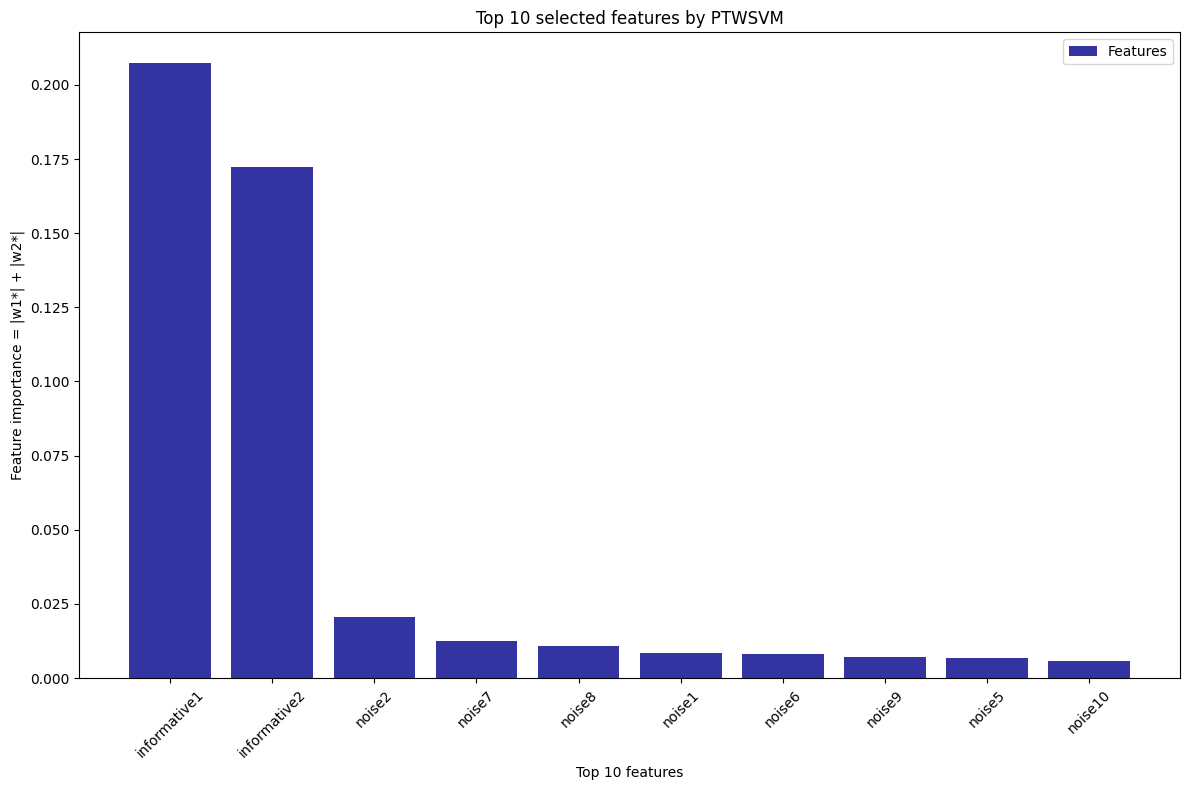

[9.99988394e-01 9.99757242e-01 1.11693915e-03 9.94167931e-01
 9.99999834e-01 9.99995524e-01 9.99456613e-01 9.99929408e-01
 2.04642692e-02 7.48136919e-03 9.99463578e-01 1.25470024e-02
 1.88777848e-02 9.99087655e-01 9.99847104e-01 9.99528334e-01
 9.98190289e-01 9.95379028e-01 9.99996505e-01 9.98921939e-01
 5.82265860e-03 9.99992663e-01 1.21071676e-03 9.91417778e-01
 9.99974333e-01 9.95896531e-01 9.99764315e-01 3.86019829e-05
 9.94299685e-01 9.99817301e-01 9.67883731e-01 9.77866990e-01
 9.96876668e-01 9.99964121e-01 7.67669941e-03 9.99677662e-01
 9.99995695e-01 9.97970993e-01 2.58455979e-04 9.03908871e-05
 9.97581751e-01 9.96670253e-01 9.90546614e-01 6.71075106e-02
 9.99966372e-01 2.08722484e-02 9.91668335e-01 5.39154822e-03
 9.98987061e-01 9.94947021e-01 9.51240689e-01 9.99952003e-01
 9.99920402e-01 9.99984814e-01 9.99945450e-01 9.99867533e-01
 9.95798590e-01 1.96341120e-02 1.34822127e-03 9.99954998e-01
 9.99662801e-01 9.86883177e-01 9.95859509e-01 9.99954889e-01
 9.99672588e-01 9.999938

In [ ]:
####################################
#  PTWSVM class usage
####################################
from sklearn.metrics import balanced_accuracy_score

# PTWSVM instanciate
ptwsvm = PTWSVM(0.5, 0.5, 0.5, 0.5) # arbitrary c1, c2, c3, c4 parameters

# Fit model on training set (uses the training set for automatically compute A, B training class specific matrices and solve the corresponding QPPs determining each hyperplane)
ptwsvm.fit(X_train, Y_train)


# Feature selection
top = 10
fs_idx, fs_weights = ptwsvm.feature_selection(top)
plt.figure(figsize = (12,8))
plt.bar(features_names[fs_idx], fs_weights, color = 'darkblue', label = 'Features', alpha = 0.8)
plt.xticks(rotation = 45)
plt.xlabel('Top {} features'.format(top))
plt.ylabel('Feature importance = |w1*| + |w2*|')
plt.title('Top {} selected features by PTWSVM'.format(top))
plt.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

# Compose ptwsvm probabilistic model
ptwsvm.fit_probabilities(X_train, Y_train, method = 'platt')
# Use predict_proba for returning posterior probabilities
p = ptwsvm.predict_proba(X_test) 
print(p)

ptsvm_preds = ptwsvm.predict(X_test)
print(balanced_accuracy_score(Y_test, ptsvm_preds))

## Boostrapping on PTWSVM with independent Feature Selection per hyperplane

In [ ]:
from sklearn.utils import resample

# Define a simple hyperparameters grid search
grid = {
    'c1': [0.5, 1],
    'c2': [0.5, 1],
    'c3': [0.5, 1],
    'c4': [0.5, 1]
}

# Number of boostrap samples
k = 5
# Number of features to be selected
top = 10

selected_fs = np.empty((top, k), dtype = str)
accuracies = np.empty(k, dtype = float)

for b in range(k):
    
    # Instantiate the PTWSVM model (recall PTWSVM only works with numpy array like objects)
    ptwsvm = PTWSVM(grid['c1'][0], grid['c2'][1], grid['c3'][1], grid['c4'][0])

    # Extract boostrap sample of the idx of X df
    # Generate Boostrap samples T_b from the whole dataset T using the boostraped idxs
    idx_b = resample(X.index, replace = True)
    X_Tb, Y_Tb = X.iloc[idx_b,:], Y.iloc[idx_b,:].to_numpy()

    # Create OOB samples for validation V_b*
    X_Vb, Y_Vb = X.iloc[X.index.difference(idx_b),:].to_numpy(), Y.iloc[X.index.difference(idx_b),:].to_numpy()

    # Fit the PTWSVM model using the T_b boostrap sample
    ptwsvm.fit(X_Tb, Y_Tb)
    ptwsvm.fit_probabilities(X_Tb, Y_Tb, method = 'platt')

    # Retrieve fs selection
    selected_fs[:,b] = ptwsvm.feature_selection(top)

    # Compute probabilities and measure performance on the OOB validation set, V_b*
    ptwsvm.predict_proba(X_Vb)
    accuracies[b] = balanced_accuracy_score(ptwsvm.predict(X_Vb), Y_Vb)
    
print(np.mean(accuracies))
print(selected_fs)

1.0
